<a href="https://colab.research.google.com/github/kanepeters/lis4693/blob/main/final-project/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Text Analysis and Visualization

Dataset Selection:

The chosen dataset contains 1000 records of bibliographic metadata from Lens.org based upon a search of scholarly articles containing the terms "generative AI" or "genAI." The results are filtered to those that have an available abstract; this field will be used for text analysis.

This dataset was chosen in order to get a better grasp on the type of scholarly research being conducted on generative AI. As it represents a technology that is changing rapidly and being actively incorporated into business strategies, the application of text analysis on this corpus may give some insight into where such developments are chiefly concentrated.

The results of the search query can be seen here: https://www.lens.org/lens/search/scholar/list?q=(%22generative%20AI%22)%20OR%20genAI&p=0&n=10&s=_score&d=%2B&f=false&e=false&l=en&authorField=author&dateFilterField=publishedYear&orderBy=%2B_score&presentation=false&preview=true&stemmed=true&useAuthorId=false

In [152]:
import requests
import io

url = "https://raw.githubusercontent.com/kanepeters/lis4693/refs/heads/main/final-project/lens-export%20FP.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

Install and import packages to perform topic modeling.

In [153]:
!pip install gensim
!pip install pyldavis
!pip install nltk
import nltk
nltk.download('stopwords')

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Import the pandas library and convert the response into a DataFrame. Then, display the first 10 rows of the dataset.

In [154]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
print(df.head(10))

               Lens ID                                              Title  \
0  000-455-752-186-559  Transforming Project Management through Data A...   
1  000-814-791-212-010  Generative AI and the social fabric of organiz...   
2  000-866-363-100-148              Implementing a Generative AI Solution   
3  001-098-325-900-002  Generative AI for feedback and collaborative k...   
4  001-489-122-670-989                                      Generative AI   
5  001-507-161-697-478  Whether and When Could Generative AI Improve C...   
6  002-238-438-289-64X  Generative AI Tools Pilot – A Guide for Enterp...   
7  003-064-494-513-094  Increasing engagement with cognitive-behaviora...   
8  003-265-518-667-129  Integrating Generative AI Chatbot Models into ...   
9  003-298-692-999-63X  Which educational approaches predict students'...   

  Date Published  Publication Year                Publication Type  \
0     2025-09-04            2025.0                 journal article   
1     2025-0

Use the "Abstract" field to perform topic modeling.

In [155]:
# Compile all the abstracts into a list
docs = df.Abstract.tolist()

Load stopwords.

In [156]:
stop_words = stopwords.words('english')

Define a function for document preprocessing.

In [162]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

## Adding custom stopwords
# Remove words that appear commonly or are redundant with respect to the domain.
custom_stopwords = ["abstract", "abstracttext", "generative", "ai", "genai", "45", "χ²", "genai’s", "al", "et", "study", "paper", "artificial", "intelligence", "students", "education", "learning", "research", "use", "tools", "using", "also", "potential", "data", "models", "challenges", "however", "results", "analysis", "findings", "may", "new", "used", "jatssec"]
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['abstract', 'abstracttext', 'generative', 'ai', 'genai', '45', 'χ²', 'genai’s', 'al', 'et', 'study', 'paper', 'artificial', 'intelligence', 'students', 'education', 'learning', 'research', 'use', 'tools', 'using', 'also', 'potential', 'data', 'models', 'challenges', 'however', 'results', 'analysis', 'findings', 'may', 'new', 'used', 'jatssec']


Perform preprocessing on all the records in the dataset; create the bag-of-words corpus. Test preprocessing using the first record in the dataset (index 0).

In [163]:
# Replace NaN values in the Abstract column with empty strings.
docs = df.Abstract.fillna('').tolist()

cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])

# Display the unprocessed abstract as a control.
print("\nOriginal document (first index):")
print(docs[0])

# Display the processed abstract to verify the preprocessing method.
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
Abstract: Generative AI (GenAI) and data analytics are emerging as transformative tools in project management. This study examines the awareness, adoption, and impact of GenAI on project outcomes through a survey of 45 project professionals across diverse industries. Using descriptive statistics and chi-square (χ²) tests, results show significant associations between GenAI adoption and improvements in schedule adherence, budget efficiency, and quality performance. However, ethical concerns such as privacy, fairness, and transparency, as well as organizational barriers such as governance gaps and resistance to change, remain challenges. The findings suggest that responsible integration and cultural readiness are vital for realizing GenAI’s full potential. Keywords: Generative AI, Project Management, Data Analytics

Cleaned document with custom stopwords:
['analytics', 'e

Train an LDA model for 5 topics.

In [164]:
# Train the LDA model for 5 topics.
lda_model = LdaModel(corpus=corpus,id2word=id2word,num_topics=5,
    random_state=30,
    passes=10,
    alpha='auto'
)

# Print the discovered topics.
topics = lda_model.print_topics(num_words=10)

print("Topics:\n")

for topic in topics:
    print(topic)

Topics:

(0, '0.005*"academic" + 0.005*"technology" + 0.005*"language" + 0.004*"ethical" + 0.003*"development" + 0.003*"applications" + 0.003*"adoption" + 0.003*"integration" + 0.003*"content" + 0.003*"framework"')
(1, '0.004*"ethical" + 0.003*"review" + 0.003*"impact" + 0.003*"science" + 0.003*"adoption" + 0.003*"higher" + 0.003*"human" + 0.003*"studies" + 0.003*"applications" + 0.003*"development"')
(2, '0.005*"design" + 0.005*"systems" + 0.005*"ethical" + 0.004*"technology" + 0.003*"content" + 0.003*"educators" + 0.003*"framework" + 0.003*"development" + 0.003*"work" + 0.003*"academic"')
(3, '0.004*"language" + 0.003*"survey" + 0.003*"large" + 0.003*"responses" + 0.003*"tasks" + 0.003*"work" + 0.002*"across" + 0.002*"future" + 0.002*"trust" + 0.002*"adoption"')
(4, '0.008*"health" + 0.005*"ethical" + 0.004*"systems" + 0.004*"human" + 0.003*"design" + 0.003*"writing" + 0.003*"academic" + 0.003*"review" + 0.003*"mental" + 0.003*"including"')


 Print the top 5 words for each topic.

In [165]:
# Print the top 5 words for each topic.
for topic_id, topic_terms_str in topics:
    terms = lda_model.get_topic_terms(topic_id, 5)
    print(f"({topic_id}, '{topic_terms_str}')")
    for num in terms:
        num = num[0]
        print(num, id2word[num])
    print()

(0, '0.005*"academic" + 0.005*"technology" + 0.005*"language" + 0.004*"ethical" + 0.003*"development" + 0.003*"applications" + 0.003*"adoption" + 0.003*"integration" + 0.003*"content" + 0.003*"framework"')
415 academic
1243 technology
373 language
16 ethical
348 development

(1, '0.004*"ethical" + 0.003*"review" + 0.003*"impact" + 0.003*"science" + 0.003*"adoption" + 0.003*"higher" + 0.003*"human" + 0.003*"studies" + 0.003*"applications" + 0.003*"development"')
16 ethical
396 review
22 impact
1601 science
2 adoption

(2, '0.005*"design" + 0.005*"systems" + 0.005*"ethical" + 0.004*"technology" + 0.003*"content" + 0.003*"educators" + 0.003*"framework" + 0.003*"development" + 0.003*"work" + 0.003*"academic"')
230 design
519 systems
16 ethical
1243 technology
225 content

(3, '0.004*"language" + 0.003*"survey" + 0.003*"large" + 0.003*"responses" + 0.003*"tasks" + 0.003*"work" + 0.002*"across" + 0.002*"future" + 0.002*"trust" + 0.002*"adoption"')
373 language
45 survey
592 large
1273 respon

Prepare the data for plotting by converting the topic words and probabilities into a pandas DataFrame.

In [166]:
topic_data = []
# Select all 5 topics.
target_topic_ids = [0, 1, 2, 3, 4]

for topic_id in target_topic_ids:
    # Retrieve the top 10 words and their probabilities for the current topic
    topic_terms = lda_model.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

# Create a dataframe with all of the topic words.
df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head(50))

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
    Topic ID          Word  Probability
0          0      academic     0.005458
1          0    technology     0.004798
2          0      language     0.004650
3          0       ethical     0.004241
4          0   development     0.003462
5          0  applications     0.003175
6          0      adoption     0.003164
7          0   integration     0.003060
8          0       content     0.002835
9          0     framework     0.002798
10         1       ethical     0.004334
11         1        review     0.003170
12         1        impact     0.003158
13         1       science     0.003078
14         1      adoption     0.003013
15         1        higher     0.002933
16         1         human     0.002931
17         1       studies     0.002916
18         1  applications     0.002892
19         1   development     0.002819
20         2        design     0.004793
21         2       systems     0.004

Visualize the top 10 words for the five topics using Altair. Display the topics as individual plots.

In [168]:
import altair as alt

# Order the words in descending order of probability.
df_plot = (
    df_topic_words
    .sort_values(["Topic ID", "Probability"], ascending=[True, False])
)

chart = (
    alt.Chart(df_plot)
    .mark_bar(color="steelblue")
    .encode(
        # Top 10 words appear in the corresponding x-axis.
        x=alt.X(
            "Word:N",
            sort=None,
            axis=alt.Axis(labelAngle=15, labelFontSize=14)
        ),
        y=alt.Y("Probability:Q"),
        tooltip=["Topic ID", "Word", "Probability"]
    )
    .properties(
        width=1000,
    )
    .facet(
        row=alt.Row(
            "Topic ID:N",
            header=alt.Header(
                title="Topic",
                labelFontSize=30,
                titleFontSize=30,
                labelAngle=0
            )
        )
    )
    .resolve_scale(
        x="independent",
        y="independent"
    )
)

chart

alt.FacetChart(...)

# Analysis of topics:

Topic 0 seems strongly related to the use of generative AI in an academic environment based upon the top two words. Topic 1 seems to reflect inquiry into ethical issues concerning the use of generative AI as indicated by top words such as "ethical", "review", and "impact." Topic 2 seems to be centered around the design of systems involving generative AI, indicated by words such as "design" and "development." Topic 3 seems related to the domain of large language models, indicated by the presence of terms such as "language," "responses," and "tasks." Topic 4 seems primarily focused on the domain of health as it relates to the use of generative AI; this could be connected to the use of programs designed to assist professionals in the related fields.

Due to the specialized nature of the corpus, namely being focused around generative AI, there is a substantial amount of overlap between topics. For instance, terms such as "academic," "development," and "ethical" appear in multiple topics.

# Task 2: Machine Learning

Install and load libraries used for machine learning.

In [121]:
!pip install sklearn

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


Load the dataset.

In [169]:
import requests
import io

url = "https://raw.githubusercontent.com/kanepeters/lis4693/refs/heads/main/final-project/lens-export%20FP.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

The Lens.org dataset did not provide for any pre-existing classification labels, so a rule-based model will be used to classify them. Abstracts which contain terms signalling that the article has a particular focus with respect to generative AI are assigned the label "1"; other articles that only deal with AI generally get the label "0".

In [170]:
# Use these keywords to designated an article as being specialized.
keywords = [
    "transformer", "llm", "large language model", "chatgpt",
    "gpt", "diffusion", "generative", "prompt", "embedding",
    "neural", "deep learning", "model"
]

# If the "text" passed to this function contains at least two keywords, return 1.
def label_text(text):
    text = str(text).lower()
    score = sum(1 for word in keywords if word in text)
    return 1 if score >= 2 else 0

# Create a copy of the dataframe for use in the machine learning task.
df_ML = df.copy()

# Fill out the label field based upon whether the abstract contains any keywords.
df_ML["Label"] = df_ML["Abstract"].fillna("").apply(label_text)

# Summarize the dataframe based upon the assignment of labels. Should add up to 1000.
df_ML["Label"].value_counts()

,count
Label,
1,554
0,446


Designate the "Abstract" field as the features and the "Label" field as the target.

In [171]:
features = df_ML["Abstract"]
target = df_ML["Label"]

target_names = ['General', 'AI']

Split the data into train and test sets.

In [172]:
from sklearn.model_selection import train_test_split

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# Split the data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Show the results of the split.
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test.
X_train = X_train.fillna('')  # Replace NaN with empty string
X_test = X_test.fillna('')   # Replace NaN with empty string

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

y_test.unique()

Training set has 800 samples.
Testing set has 200 samples.
Preprocessing training data...
Preprocessing test data...


array([1, 0])

Run different classifiers (Naive Bayes, Logistic Regression, Support Vector Machine, AdaBoost, Random Forest) on the dataset; determine which one performs best based on the evaluation metrics (accuracy, recall, precision, f1 score).

In [173]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")
ada_classifier = AdaBoostClassifier()
random_classifier = RandomForestClassifier()

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

print("Training Adaboost classifier...")
ada_classifier.fit(train_preprocessed, y_train)

print("Training Random Forest classifier...")
random_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...
Training Adaboost classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Training Random Forest classifier...


RandomForestClassifier()

In [174]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)
ada_predictions = ada_classifier.predict(test_preprocessed)
random_predictions = random_classifier.predict(test_preprocessed)

In [175]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))
print("ADA Accuracy:", np.mean(ada_predictions == y_test))
print("RF Accuracy:", np.mean(random_predictions == y_test))

NB Accuracy: 0.61
SVM Accuracy: 0.76
LR Accuracy: 0.68
ADA Accuracy: 0.92
RF Accuracy: 0.78


In this case, the AdaBoost classifier had the highest accuracy at 92%.

To further evaluate model performance, run the classification report for all of the classifiers to obtain evaluation metrics.

In [146]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))
print(classification_report(y_test, ada_predictions, target_names=target_names))
print(classification_report(y_test, random_predictions, target_names=target_names))

              precision    recall  f1-score   support

     General       0.83      0.06      0.11        82
          AI       0.60      0.99      0.75       118

    accuracy                           0.61       200
   macro avg       0.72      0.53      0.43       200
weighted avg       0.70      0.61      0.49       200

              precision    recall  f1-score   support

     General       0.65      0.48      0.55        82
          AI       0.69      0.82      0.75       118

    accuracy                           0.68       200
   macro avg       0.67      0.65      0.65       200
weighted avg       0.68      0.68      0.67       200

              precision    recall  f1-score   support

     General       0.85      0.98      0.91        82
          AI       0.98      0.88      0.93       118

    accuracy                           0.92       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.92      0.92       200

              preci

Generate the classification report for the Support Vector Machine classifier.

In [180]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [179]:
print("Best SVM Parameters")
print(svm_best.best_params_)

best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, best_svm_predictions, target_names=target_names))

Best SVM Parameters
{'C': 10}
Best SVM Accuracy: 0.76
              precision    recall  f1-score   support

     General       0.69      0.76      0.72        82
          AI       0.82      0.76      0.79       118

    accuracy                           0.76       200
   macro avg       0.75      0.76      0.76       200
weighted avg       0.77      0.76      0.76       200



The AdaBoost classifier performed the best among all classifiers. Generate the confusion matrix using the AdaBoost classifier.

(array([0.5, 1.5]), [Text(0.5, 0, 'General'), Text(1.5, 0, 'AI')])

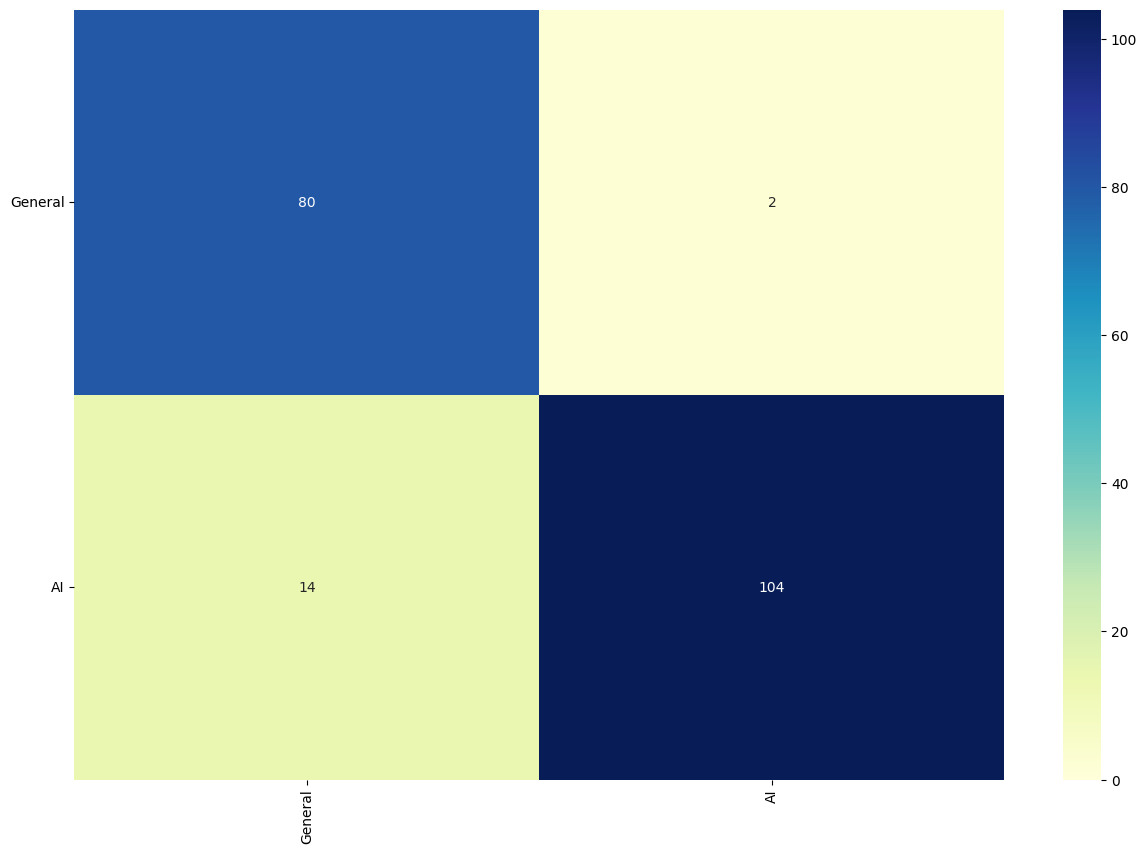

In [178]:
%matplotlib inline
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, ada_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

# Model Evaluation

This confusion matrix shows the number of abstracts that AdaBoost correctly and incorrectly classified as either having a special emphasis on a generative AI topic or being only generally related to generative AI.

Based on the visualization, the model correctly classified 80 abstracts as "General" but incorrectly classified 14 abstracts as "General" when they were considered "AI." Conversely, the model correctly classified 104 abstracts as "AI" but incorrectly classified only 2 abstracts as "AI" when they were considered "General."

These results should be interpreted while being aware of the methodology for this analysis; namely, the generation of labels for the unlabeled dataset.

Export output files.

In [181]:
df_topic_words.to_csv("topic_words.csv", index=False)
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": ada_predictions
})

predictions_df.to_csv("classification_results.csv", index=False)
conf_matrix_df.to_csv("confusion_matrix.csv")